<a href="https://colab.research.google.com/github/mehaksingh0210/Intelligent-Excuse-Generator/blob/main/CUSTOMER_BEHAVIOUR_ANALYSIS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mehmettahiraslan/customer-shopping-dataset")

print("Path to dataset files:", path)

100%|██████████| 1.63M/1.63M [00:00<00:00, 151MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/mehmettahiraslan/customer-shopping-dataset/versions/2


In [2]:
import pandas as pd
import os

print(os.listdir(path))

['customer_shopping_data.csv']


In [3]:
df = pd.read_csv(path + "/customer_shopping_data.csv")
df.head()

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,5/8/2022,Kanyon
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,9/11/2021,Metrocity
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,16/05/2021,Metropol AVM
4,I337046,C189076,Female,53,Books,4,60.60,Cash,24/10/2021,Kanyon


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv(path + "/customer_shopping_data.csv")

In [7]:
df.head()

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,5/8/2022,Kanyon
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,9/11/2021,Metrocity
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,16/05/2021,Metropol AVM
4,I337046,C189076,Female,53,Books,4,60.60,Cash,24/10/2021,Kanyon


In [8]:
df.columns

Index(['invoice_no', 'customer_id', 'gender', 'age', 'category', 'quantity',
       'price', 'payment_method', 'invoice_date', 'shopping_mall'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99457 entries, 0 to 99456
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   invoice_no      99457 non-null  object 
 1   customer_id     99457 non-null  object 
 2   gender          99457 non-null  object 
 3   age             99457 non-null  int64  
 4   category        99457 non-null  object 
 5   quantity        99457 non-null  int64  
 6   price           99457 non-null  float64
 7   payment_method  99457 non-null  object 
 8   invoice_date    99457 non-null  object 
 9   shopping_mall   99457 non-null  object 
dtypes: float64(1), int64(2), object(7)
memory usage: 7.6+ MB


# **Import Libraries**

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

# **Load Dataset**

In [11]:
df = pd.read_csv(path + "/customer_shopping_data.csv")

df.head()

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,5/8/2022,Kanyon
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,9/11/2021,Metrocity
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,16/05/2021,Metropol AVM
4,I337046,C189076,Female,53,Books,4,60.60,Cash,24/10/2021,Kanyon


# **Data Exploration**

In [12]:
df.shape

(99457, 10)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99457 entries, 0 to 99456
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   invoice_no      99457 non-null  object 
 1   customer_id     99457 non-null  object 
 2   gender          99457 non-null  object 
 3   age             99457 non-null  int64  
 4   category        99457 non-null  object 
 5   quantity        99457 non-null  int64  
 6   price           99457 non-null  float64
 7   payment_method  99457 non-null  object 
 8   invoice_date    99457 non-null  object 
 9   shopping_mall   99457 non-null  object 
dtypes: float64(1), int64(2), object(7)
memory usage: 7.6+ MB


In [15]:
df.describe()

,age,quantity,price
count,99457.000000,99457.000000,99457.000000
mean,43.427089,3.003429,689.256321
std,14.990054,1.413025,941.184567
min,18.000000,1.000000,5.230000
25%,30.000000,2.000000,45.450000
50%,43.000000,3.000000,203.300000
75%,56.000000,4.000000,1200.320000
max,69.000000,5.000000,5250.000000


# **Data Cleaning**

In [16]:
df.isnull().sum()

,0
invoice_no,0
customer_id,0
gender,0
age,0
category,0
quantity,0
price,0
payment_method,0
invoice_date,0
shopping_mall,0


In [17]:
df.duplicated().sum()

np.int64(0)

In [19]:
df.drop_duplicates(inplace=True)

# **Feature Engineering**

In [22]:
df["total_sales"] = df["quantity"] * df["price"]
df['invoice_date'] = pd.to_datetime(df['invoice_date'], dayfirst=True)
df['Month'] = df['invoice_date'].dt.month_name()

# **EDA Section**

**1. Gender Distribution**

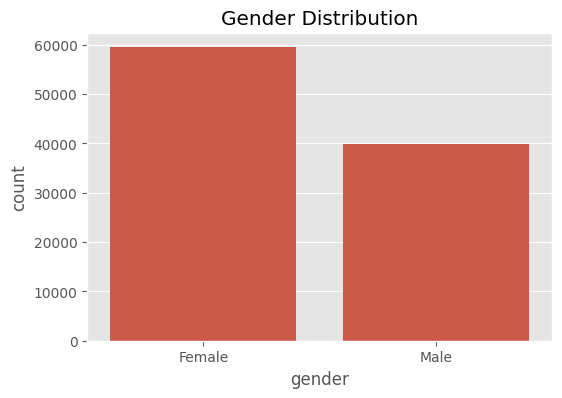

In [23]:
plt.figure(figsize=(6,4))

sns.countplot(
x='gender',
data=df
)

plt.title("Gender Distribution")

plt.show()

**2. Age Distribution**

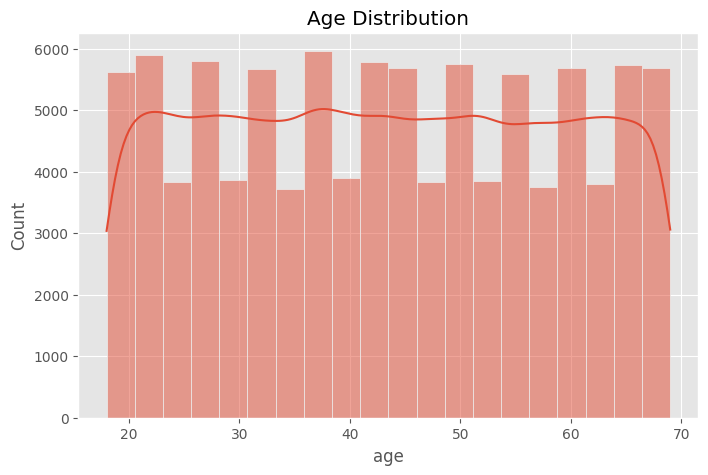

In [24]:
plt.figure(figsize=(8,5))

sns.histplot(
df['age'],
bins=20,
kde=True
)

plt.title("Age Distribution")

plt.show()

**3. Product Categories**

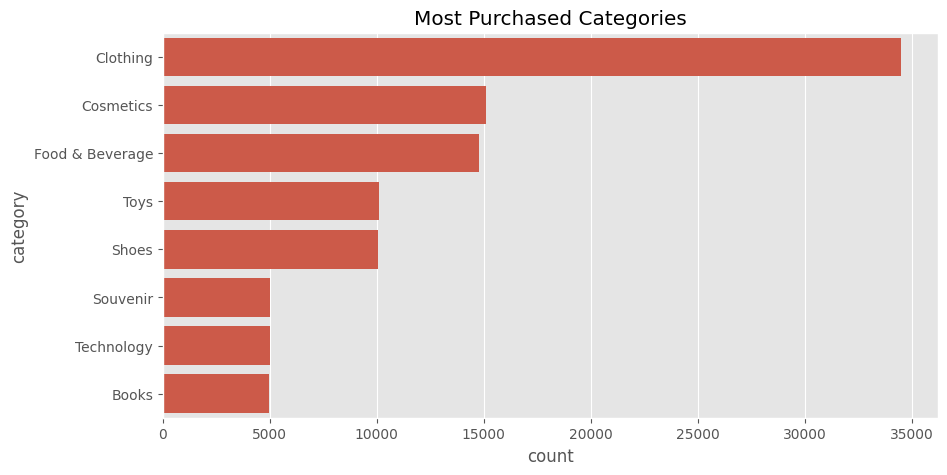

In [25]:
plt.figure(figsize=(10,5))

sns.countplot(
y='category',
data=df,
order=df['category'].value_counts().index
)

plt.title("Most Purchased Categories")

plt.show()

**4. Revenue by Category**

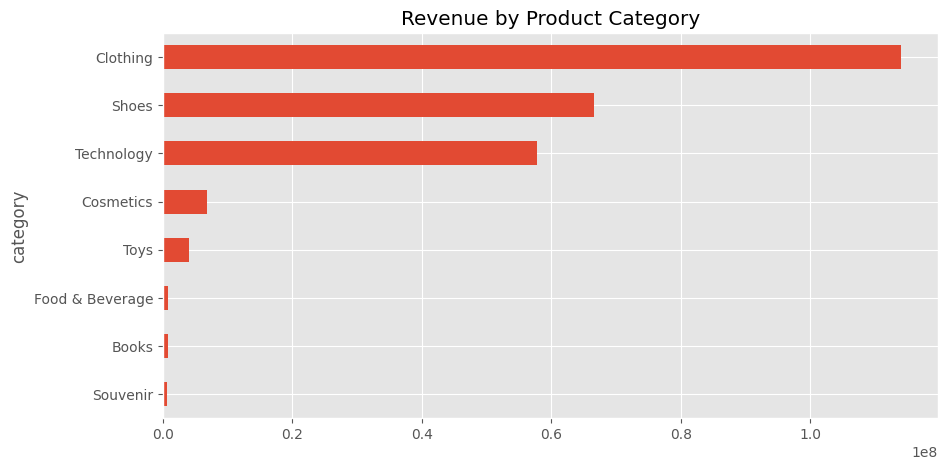

In [26]:
category_sales = df.groupby('category')['total_sales'].sum().sort_values()
category_sales.plot(
kind='barh',
figsize=(10,5)
)

plt.title("Revenue by Product Category")

plt.show()

**5. Payment Method Preference**

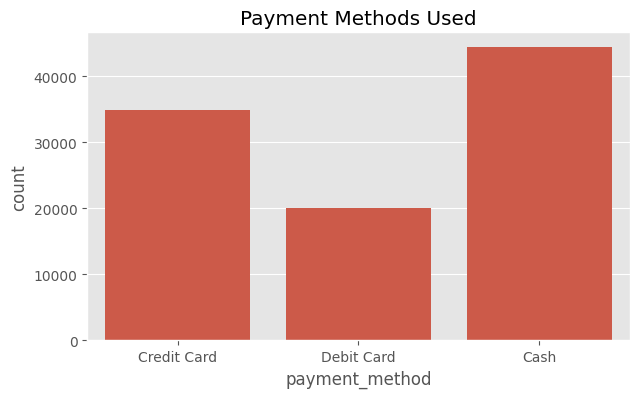

In [27]:
plt.figure(figsize=(7,4))

sns.countplot(
x='payment_method',
data=df
)

plt.title("Payment Methods Used")

plt.show()

**6. Top Shopping Malls**

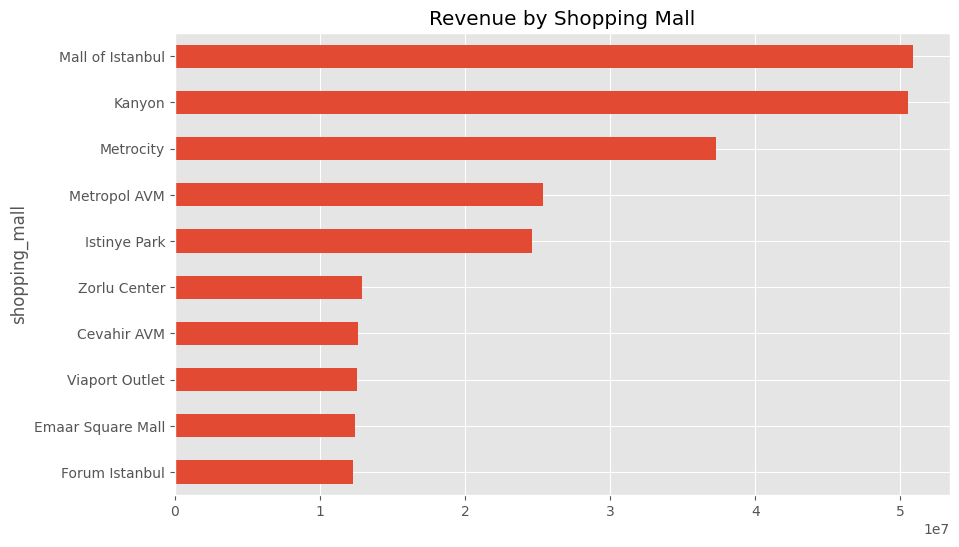

In [28]:
mall_sales = df.groupby(
'shopping_mall'
)['total_sales'].sum().sort_values()
mall_sales.plot(
kind='barh',
figsize=(10,6)
)

plt.title("Revenue by Shopping Mall")

plt.show()

**7. Monthly Sales Trend**

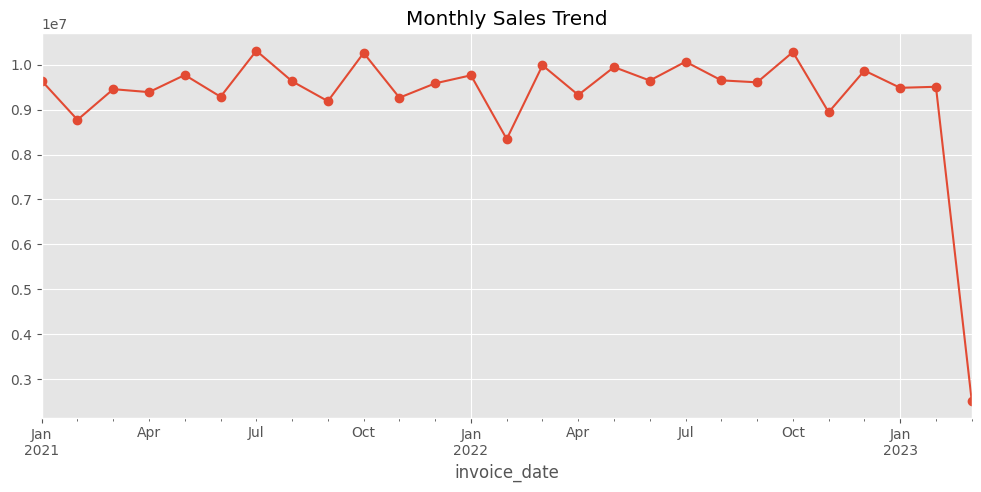

In [29]:
monthly_sales = df.groupby(
df['invoice_date'].dt.to_period('M')
)['total_sales'].sum()
monthly_sales.plot(
figsize=(12,5),
marker='o'
)

plt.title("Monthly Sales Trend")

plt.show()

**8. Age vs Spending**

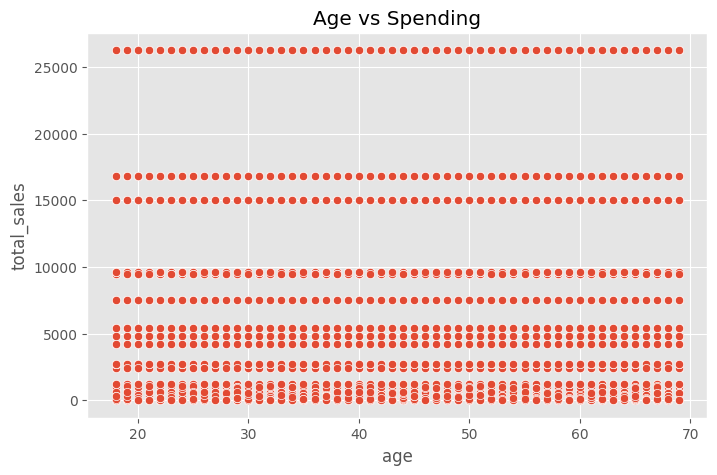

In [30]:
plt.figure(figsize=(8,5))

sns.scatterplot(
x='age',
y='total_sales',
data=df
)

plt.title("Age vs Spending")

plt.show()

**9. Correlation Heatmap**

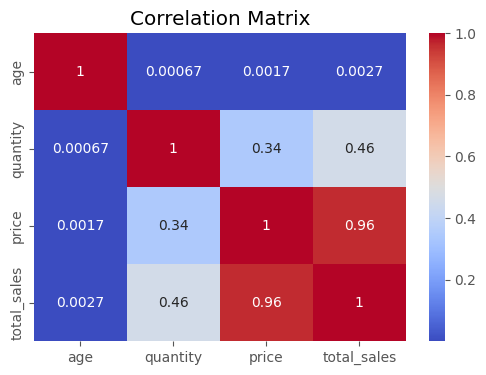

In [32]:
numeric_df = df[['age','quantity','price','total_sales']]
plt.figure(figsize=(6,4))

sns.heatmap(
numeric_df.corr(),
annot=True,
cmap='coolwarm'
)

plt.title("Correlation Matrix")

plt.show()

# **Customer Segmentation**

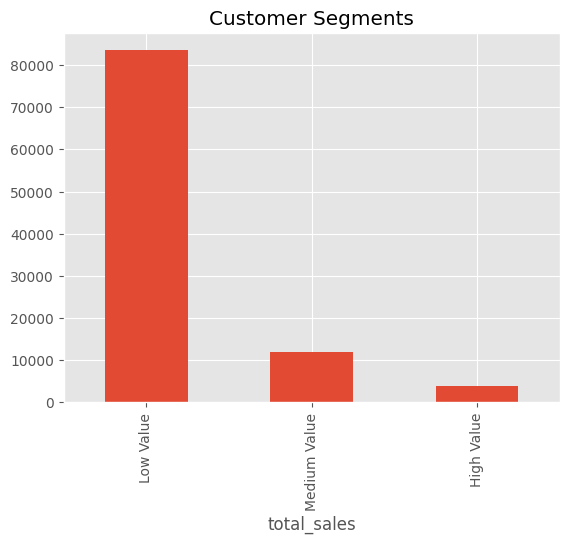

In [34]:
customer_spending = df.groupby(
'customer_id'
)['total_sales'].sum()
def segment(x):

    if x < 5000:
        return "Low Value"

    elif x < 15000:
        return "Medium Value"

    else:
        return "High Value"
segments = customer_spending.apply(segment)
segments.value_counts()
segments.value_counts().plot(
kind='bar'
)

plt.title("Customer Segments")

plt.show()

# **Business Insights**

## Key Insights

1. Clothing and Shoes are among the most purchased categories.

2. Certain shopping malls generate significantly higher revenue.

3. Credit Card and Cash are the most preferred payment methods.

4. Customers aged between 25–50 contribute a large portion of purchases.

5. High-value customers generate a major share of total sales.

6. Sales fluctuate monthly, indicating seasonal buying behavior.

# **Recommendations**



1. Focus marketing campaigns on top-selling categories.

2. Introduce loyalty rewards for high-value customers.

3. Offer personalized promotions to medium-value customers.

4. Strengthen partnerships with high-performing shopping malls.

5. Encourage digital payments through cashback offers.

6. Run promotional campaigns during low-sales months.